### Import liberaries

In [ ]:
import os
import json
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab.patches import cv2_imshow

### Loading data

In [ ]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# Download latest version
path = kagglehub.competition_download('filament-segmentation-2026')

print("Path to competition files:", path)

100%|██████████| 671M/671M [00:08<00:00, 81.1MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/filament-segmentation-2026


### Analising data.

In [ ]:
data = r'/root/.cache/kagglehub/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026/train/train_images'

In [ ]:
images = sorted(glob.glob(data + '/*'))

In [ ]:
image_names = sorted(os.listdir(data))

print(f"Total number of train images: {len(image_names)}")

Total number of train images: 707


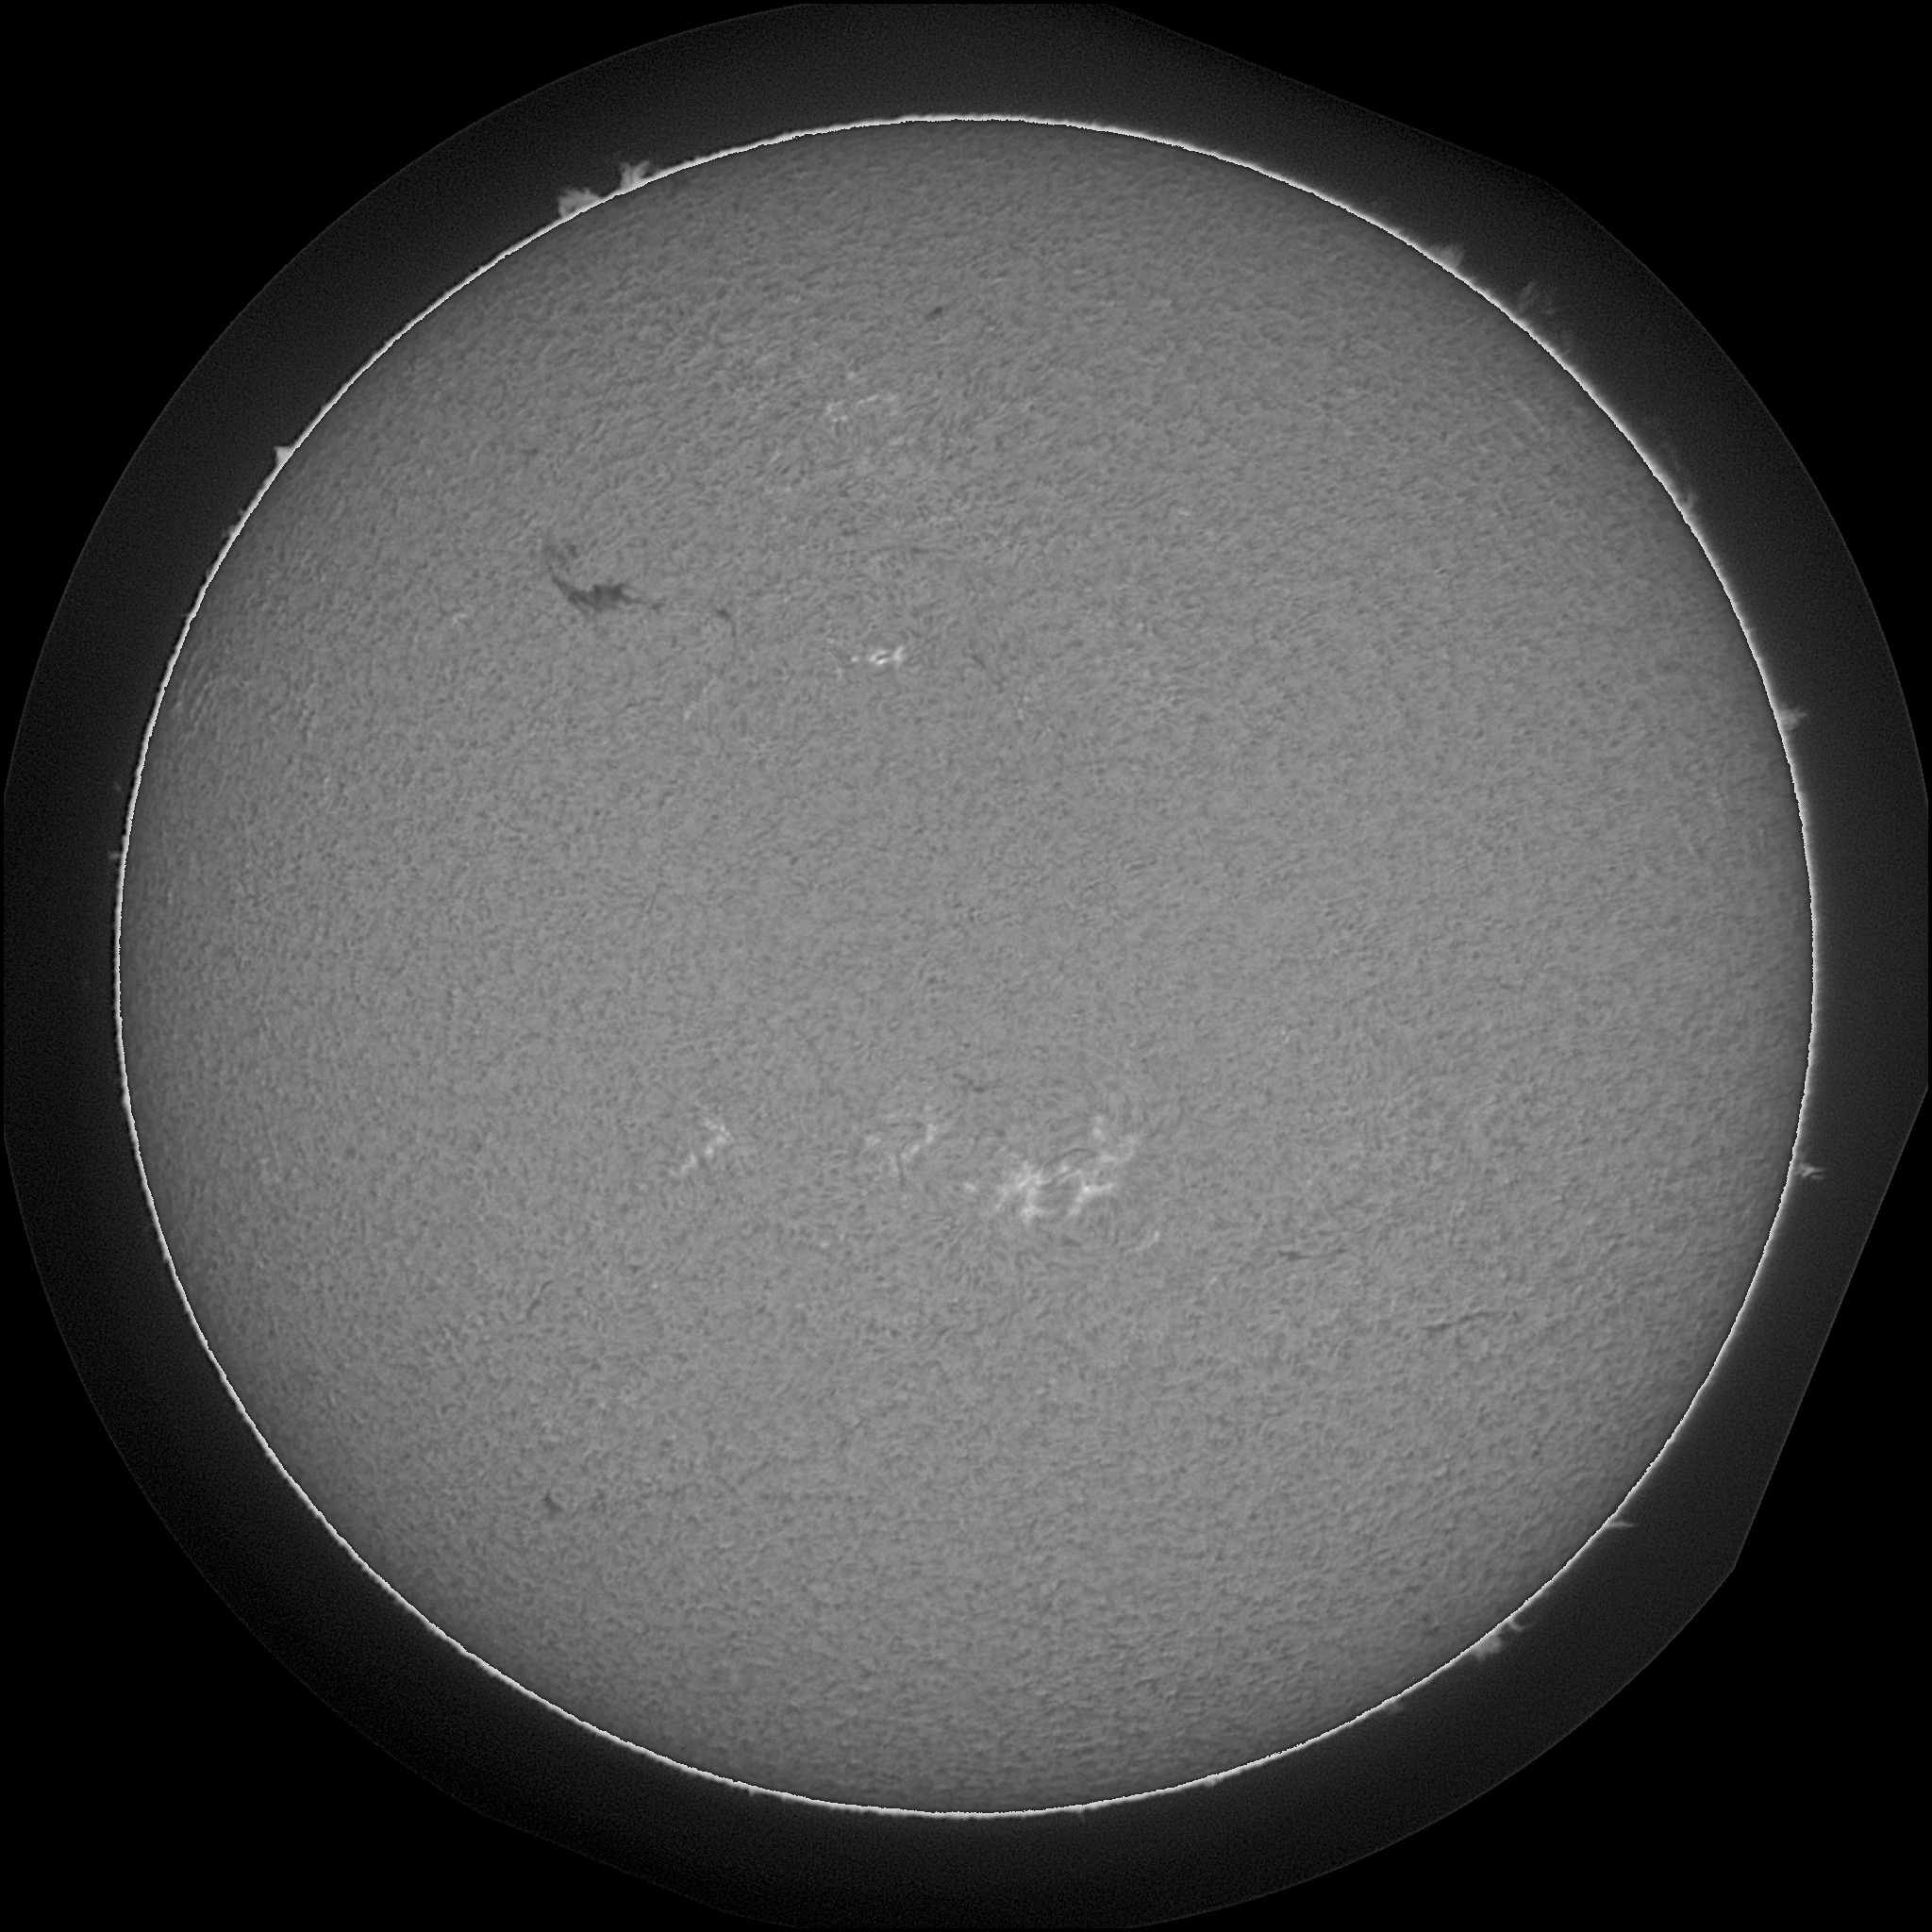

In [ ]:
img = cv2.imread(images[5])
cv2_imshow(img)

In [ ]:
img_path = os.path.join(data, image_names[5])
cv2.imread(img_path)
print(f"Image dimensions: {img.shape}")

Image dimensions: (2048, 2048, 3)


In [ ]:
# Path
BASE_DIR = '/root/.cache/kagglehub/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026'
ANN_PATH = os.path.join(BASE_DIR, 'train', 'MAGFiLO_1.0_Annotations_kaggle2026_train.json')

In [ ]:
# Reading json path.
with open(ANN_PATH, 'r') as f:
    coco_data = json.load(f)

In [ ]:
# Main keys in json.
print("Json Columns:",list(coco_data.keys()))
print('-' * 90)

In [ ]:
# Convert the Photos section to a table and display columns.
df_images = pd.DataFrame(coco_data['images'])
print("Images Columns:", list(df_images.columns))
display(df_images.head())
print('-' * 90)

In [ ]:
# Converting the filament section (annotations) to a table and displaying the columns.
df_annotations = pd.DataFrame(coco_data['annotations'])
print("Annotations Columns:", list(df_annotations.columns))
display(df_annotations.head())

In [ ]:
sample_img_id = df_images['id'].iloc[0]
photo_annotations = df_annotations[df_annotations['image_id'] == sample_img_id]
print(f"Number of {sample_img_id} filaments: {len(photo_annotations)}")